In [48]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
from utils import julio
import importlib
importlib.reload(julio)
import pandas as pd
import src.observables as obs
import utils.io as io

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)


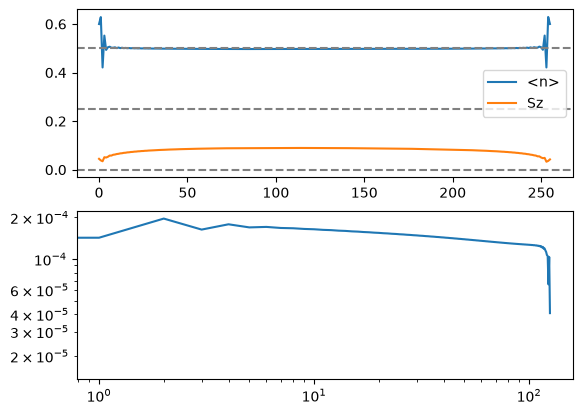

In [46]:
fig, ax = plt.subplots(2)
for nval in (256,):
    seldf = julio.select_N_dv_from_df(nval, 3.6, df)
    ax[0].plot(seldf["ntot_expect"].values[0], label='<n>')
    ax[0].plot(np.abs(seldf["sz_expect"].values[0]), label='Sz')
    ax[1].loglog(np.abs(seldf["spin2vec"].values[0]))
ax[0].axhline(0.5, ls='--', c='gray')
ax[0].axhline(0.25, ls='--', c='gray')
ax[0].axhline(0.0, ls='--', c='gray')
ax[0].legend()

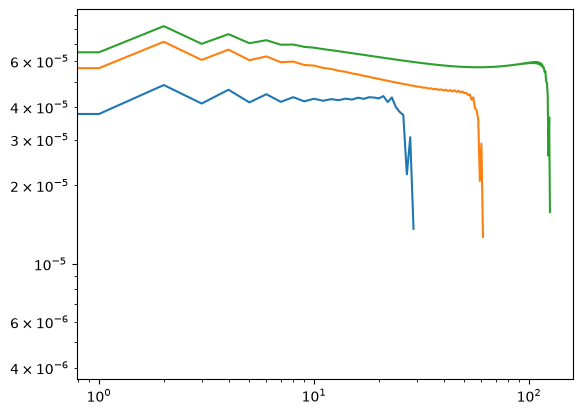

In [37]:
for nval in (64, 128, 256):
    seldf = julio.select_N_dv_from_df(nval, 3.7, df)
    plt.loglog(np.abs(seldf["spin2vec"].values[0]))


In [49]:
DATA_ROOT = '../../data/iDMRG/'
REQ_DATA = 'scanChi800'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if ".h5" in f]

def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : np.mean(psi.expectation_value("Sz")), 
        'mean_fill' : np.mean(psi.expectation_value("Ntot")),
        'model_params' : model_params, 
        'diagnostics' : metadata['diagnostics']
    }
    return row_dict
    
df_i = pd.DataFrame([atomic_action(f) for f in file_list])
df_i = df_i.sort_values('dV')

In [ ]:
psipm = df[np.isclose(df['dV'], 3.1)]['psi'].iloc[0]
distrange = 100
print("correlation legnth = ", psipm.correlation_length2())
charge_corr_pm = obs.charge_corr(psipm, length=distrange, connected=True)
charge_corr_pm_w_sign =  psipm.correlation_function("Ntot", "Ntot", [0], distrange)[0] - (psipm.expectation_value("Ntot")[0])**2
calc_Kc = (np.pi / 2.0) * np.sum(charge_corr_pm_w_sign)
plt.plot(charge_corr_pm, label="iDMRG")
plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")
plt.yscale('log')
plt.xscale('log')
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<\rho(x) \rho(0)> - <\rho(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()
print("computed Kc = ", calc_Kc)
print("naive bosonization Kc = ", bosn_Kc)
0.07 * np.pi**2